# 90 Commissioning (flagship)

KOH first fill, wetting, residual oxygen, formation, **grid power in**, rest, first charge, H2/O2, carbonation risk, temperature. Plot every engineer-relevant signal.

**Requirements:** `IA-SYS-020`, `IA-SYS-021`, `IA-GRD-001`.

## Sequence (verification-scaled seconds; engineering analog in hours)

| $t$ | Action |
| --- | --- |
| $0$–$600\,\mathrm{s}$ | Dry vessel, residual air $\mathrm{O_2}$, fans on |
| $600$–$2400\,\mathrm{s}$ | $6\,\mathrm{M}$ KOH make-up fill into anode pores |
| $2400$–$3600\,\mathrm{s}$ | Rest / wetting / residual $\mathrm{O_2}$ |
| $3600$–$7200\,\mathrm{s}$ | First charge from grid, OER + HER, $T$ rise |

Chemistry: IA-SYS-020/021. Grid: IA-GRD-001. Same `PlantModel` as decade 40.


## Process overview

Commissioning is dry vessel → $6\,\mathrm{M}$ KOH fill and wetting → rest (residual $\mathrm{O_2}$) → first grid charge through OER with parasitic HER.

Each plot section below states what it illustrates and the equations that govern that signal. Temperatures in $\mathrm{K}$, power in $\mathrm{W}$, current in $\mathrm{A}$, voltage in $\mathrm{V}$.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.plant import PlantModel
from plant_sim.scenarios.mission import commissioning_inputs

plant = PlantModel(P)
res = plant.simulate((0, 7200), inputs=commissioning_inputs(P), y0=plant.y0(filled=False), n_eval=360, rtol=1e-4)
t, a, y = res["t"], res["alg"], res["y"]
b = plant.blocks

## Grid power command

### What this plot illustrates

Grid active-power command $P_\mathrm{grid}(t)$ during commissioning: near-zero through fill/rest, then first charge from the grid (IA-GRD-001).

### Governing equations

On charge, $P_\mathrm{grid}\approx V_\mathrm{cell} I_\mathrm{cell}/\eta_\mathrm{pcs}$. Power in $\mathrm{W}$.


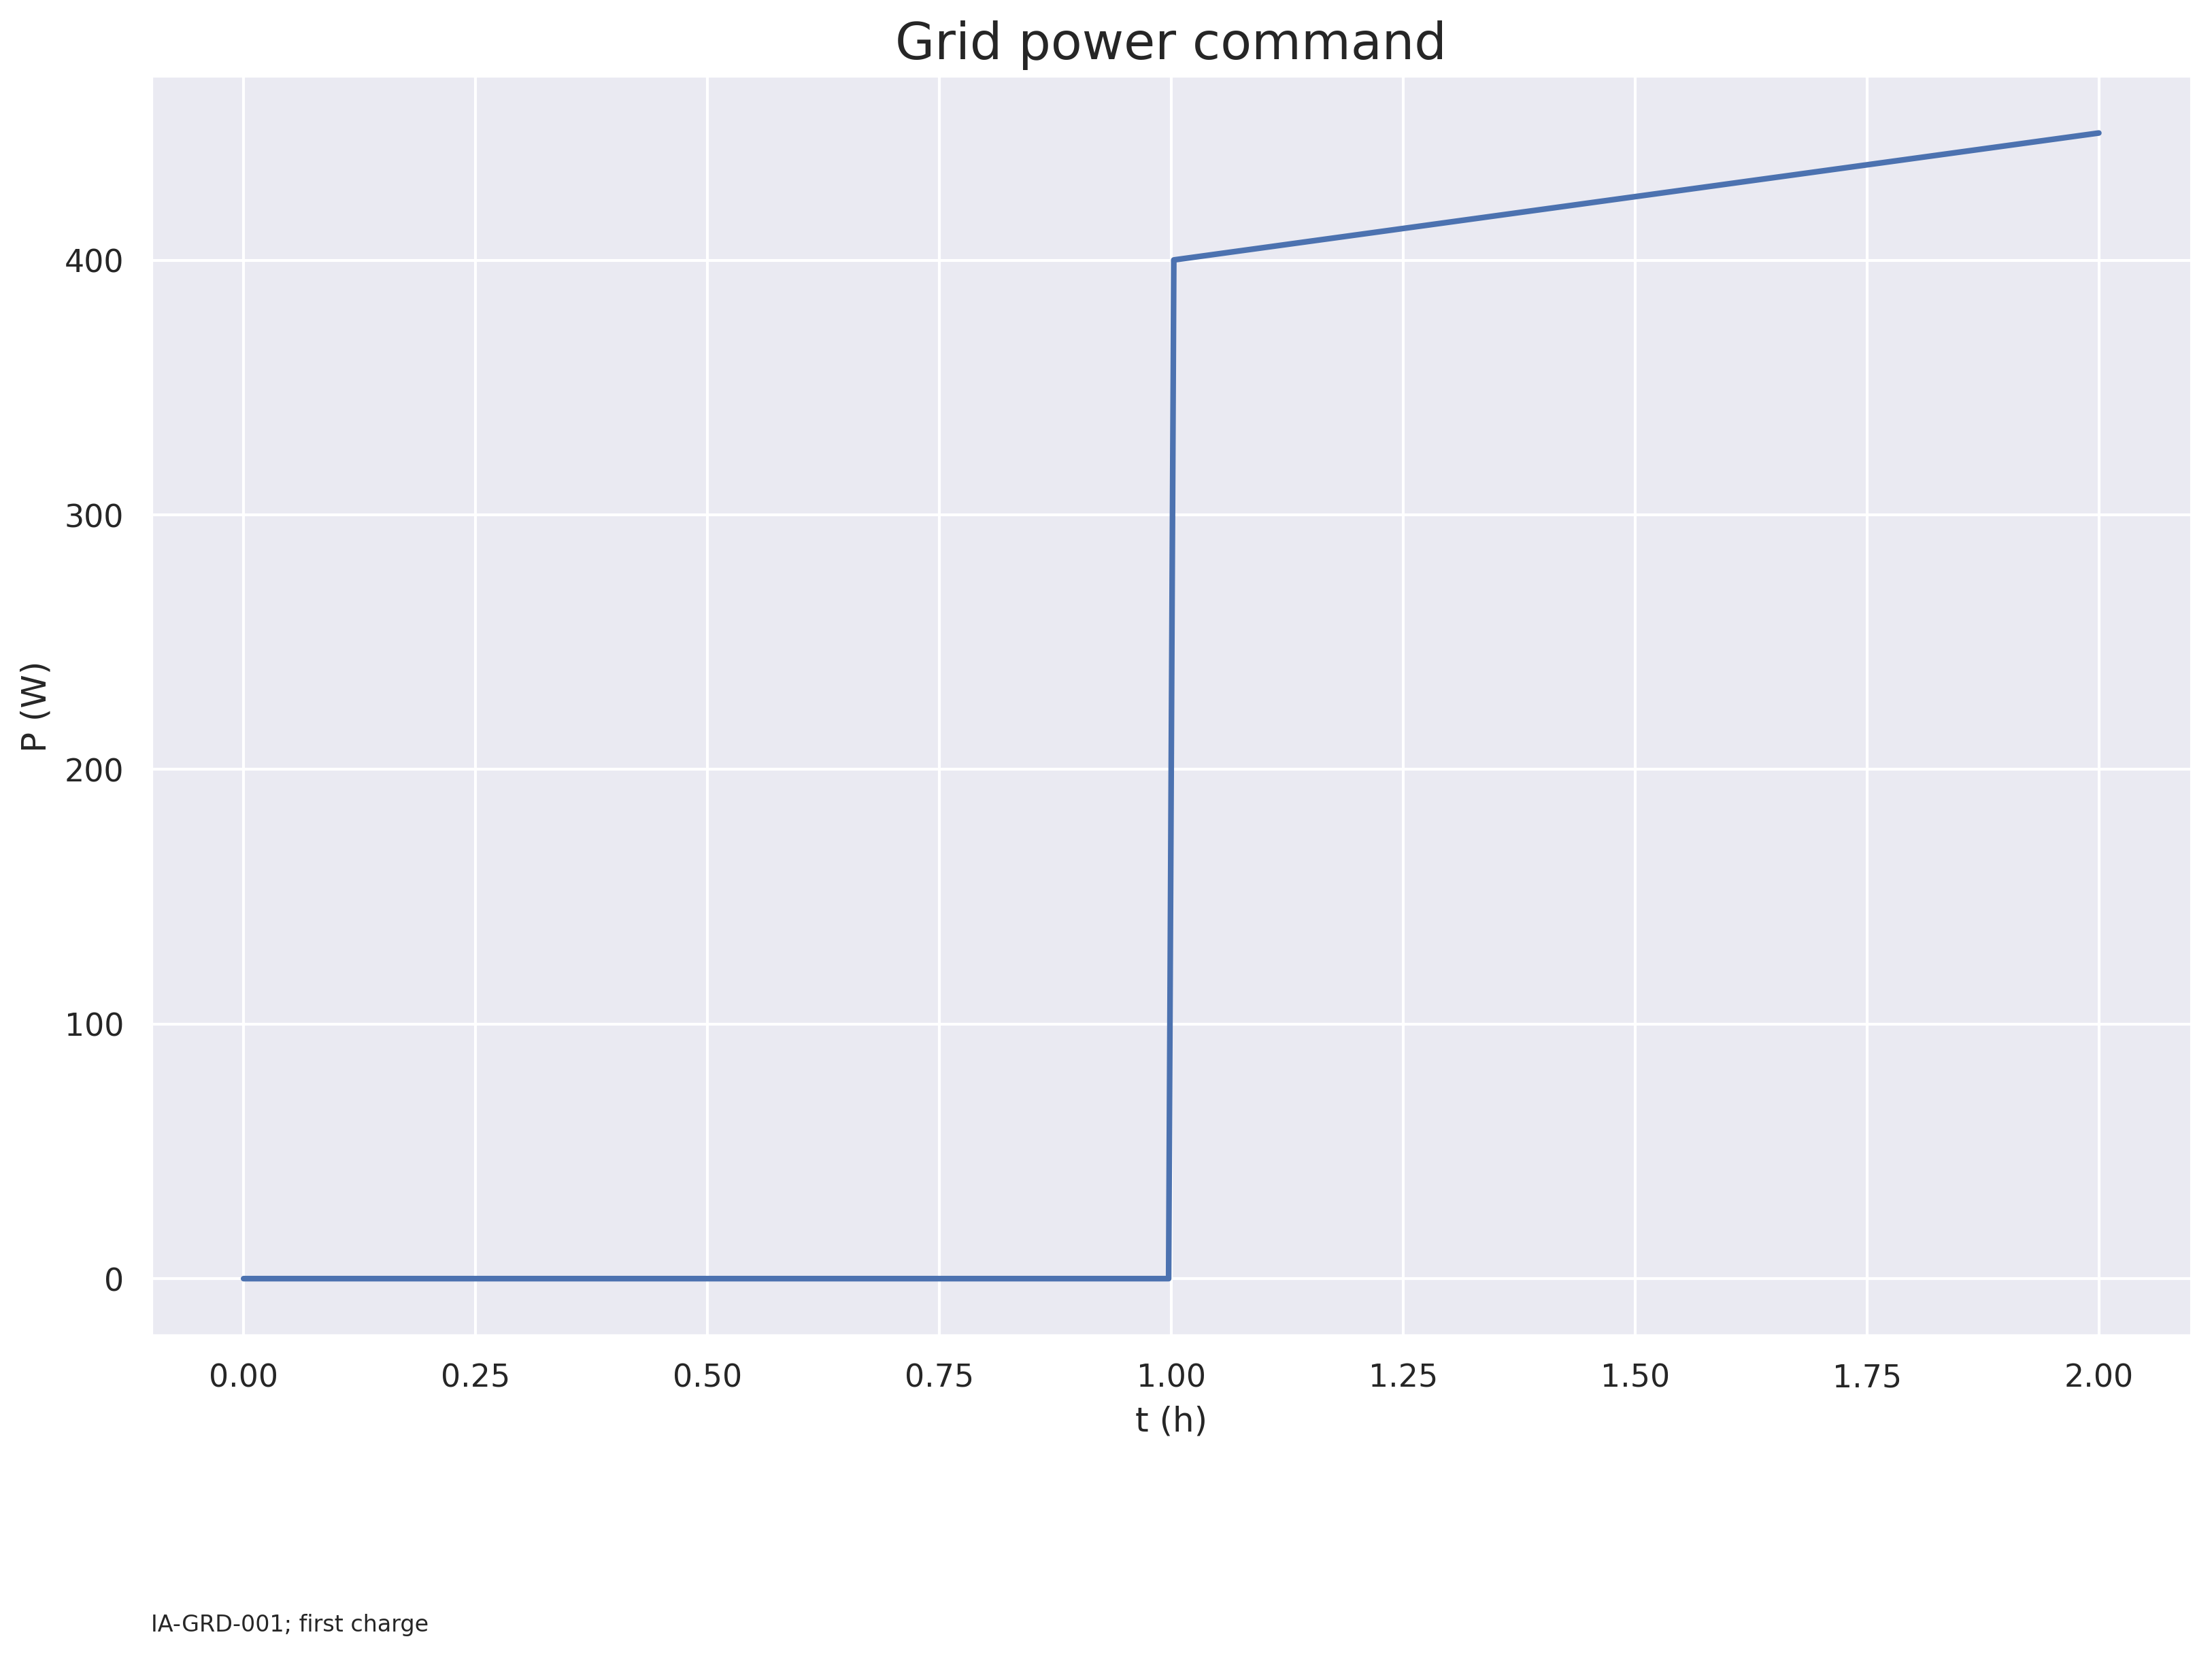

In [4]:
plot_frame = pd.DataFrame({"t": t / 3600, "P_grid_W": a["P_grid_W"]})
fig, ax = plt.subplots()
sns.lineplot(data=plot_frame, x="t", y="P_grid_W", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("P (W)")
ax.set_title("Grid power command")
ax.text(0.0, -0.22, "IA-GRD-001; first charge", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Cell current

### What this plot illustrates

Cell current drawn once the PCS applies the grid charge command. Zero during dry/fill/rest; rises on first charge through OER (+ HER share).

### Governing equations

$I_\mathrm{cell}=P_\mathrm{dc}/V_\mathrm{cell}$ with $I_\mathrm{Fe}+I_\mathrm{HER}=I_\mathrm{OER}$ on charge. Current in $\mathrm{A}$.


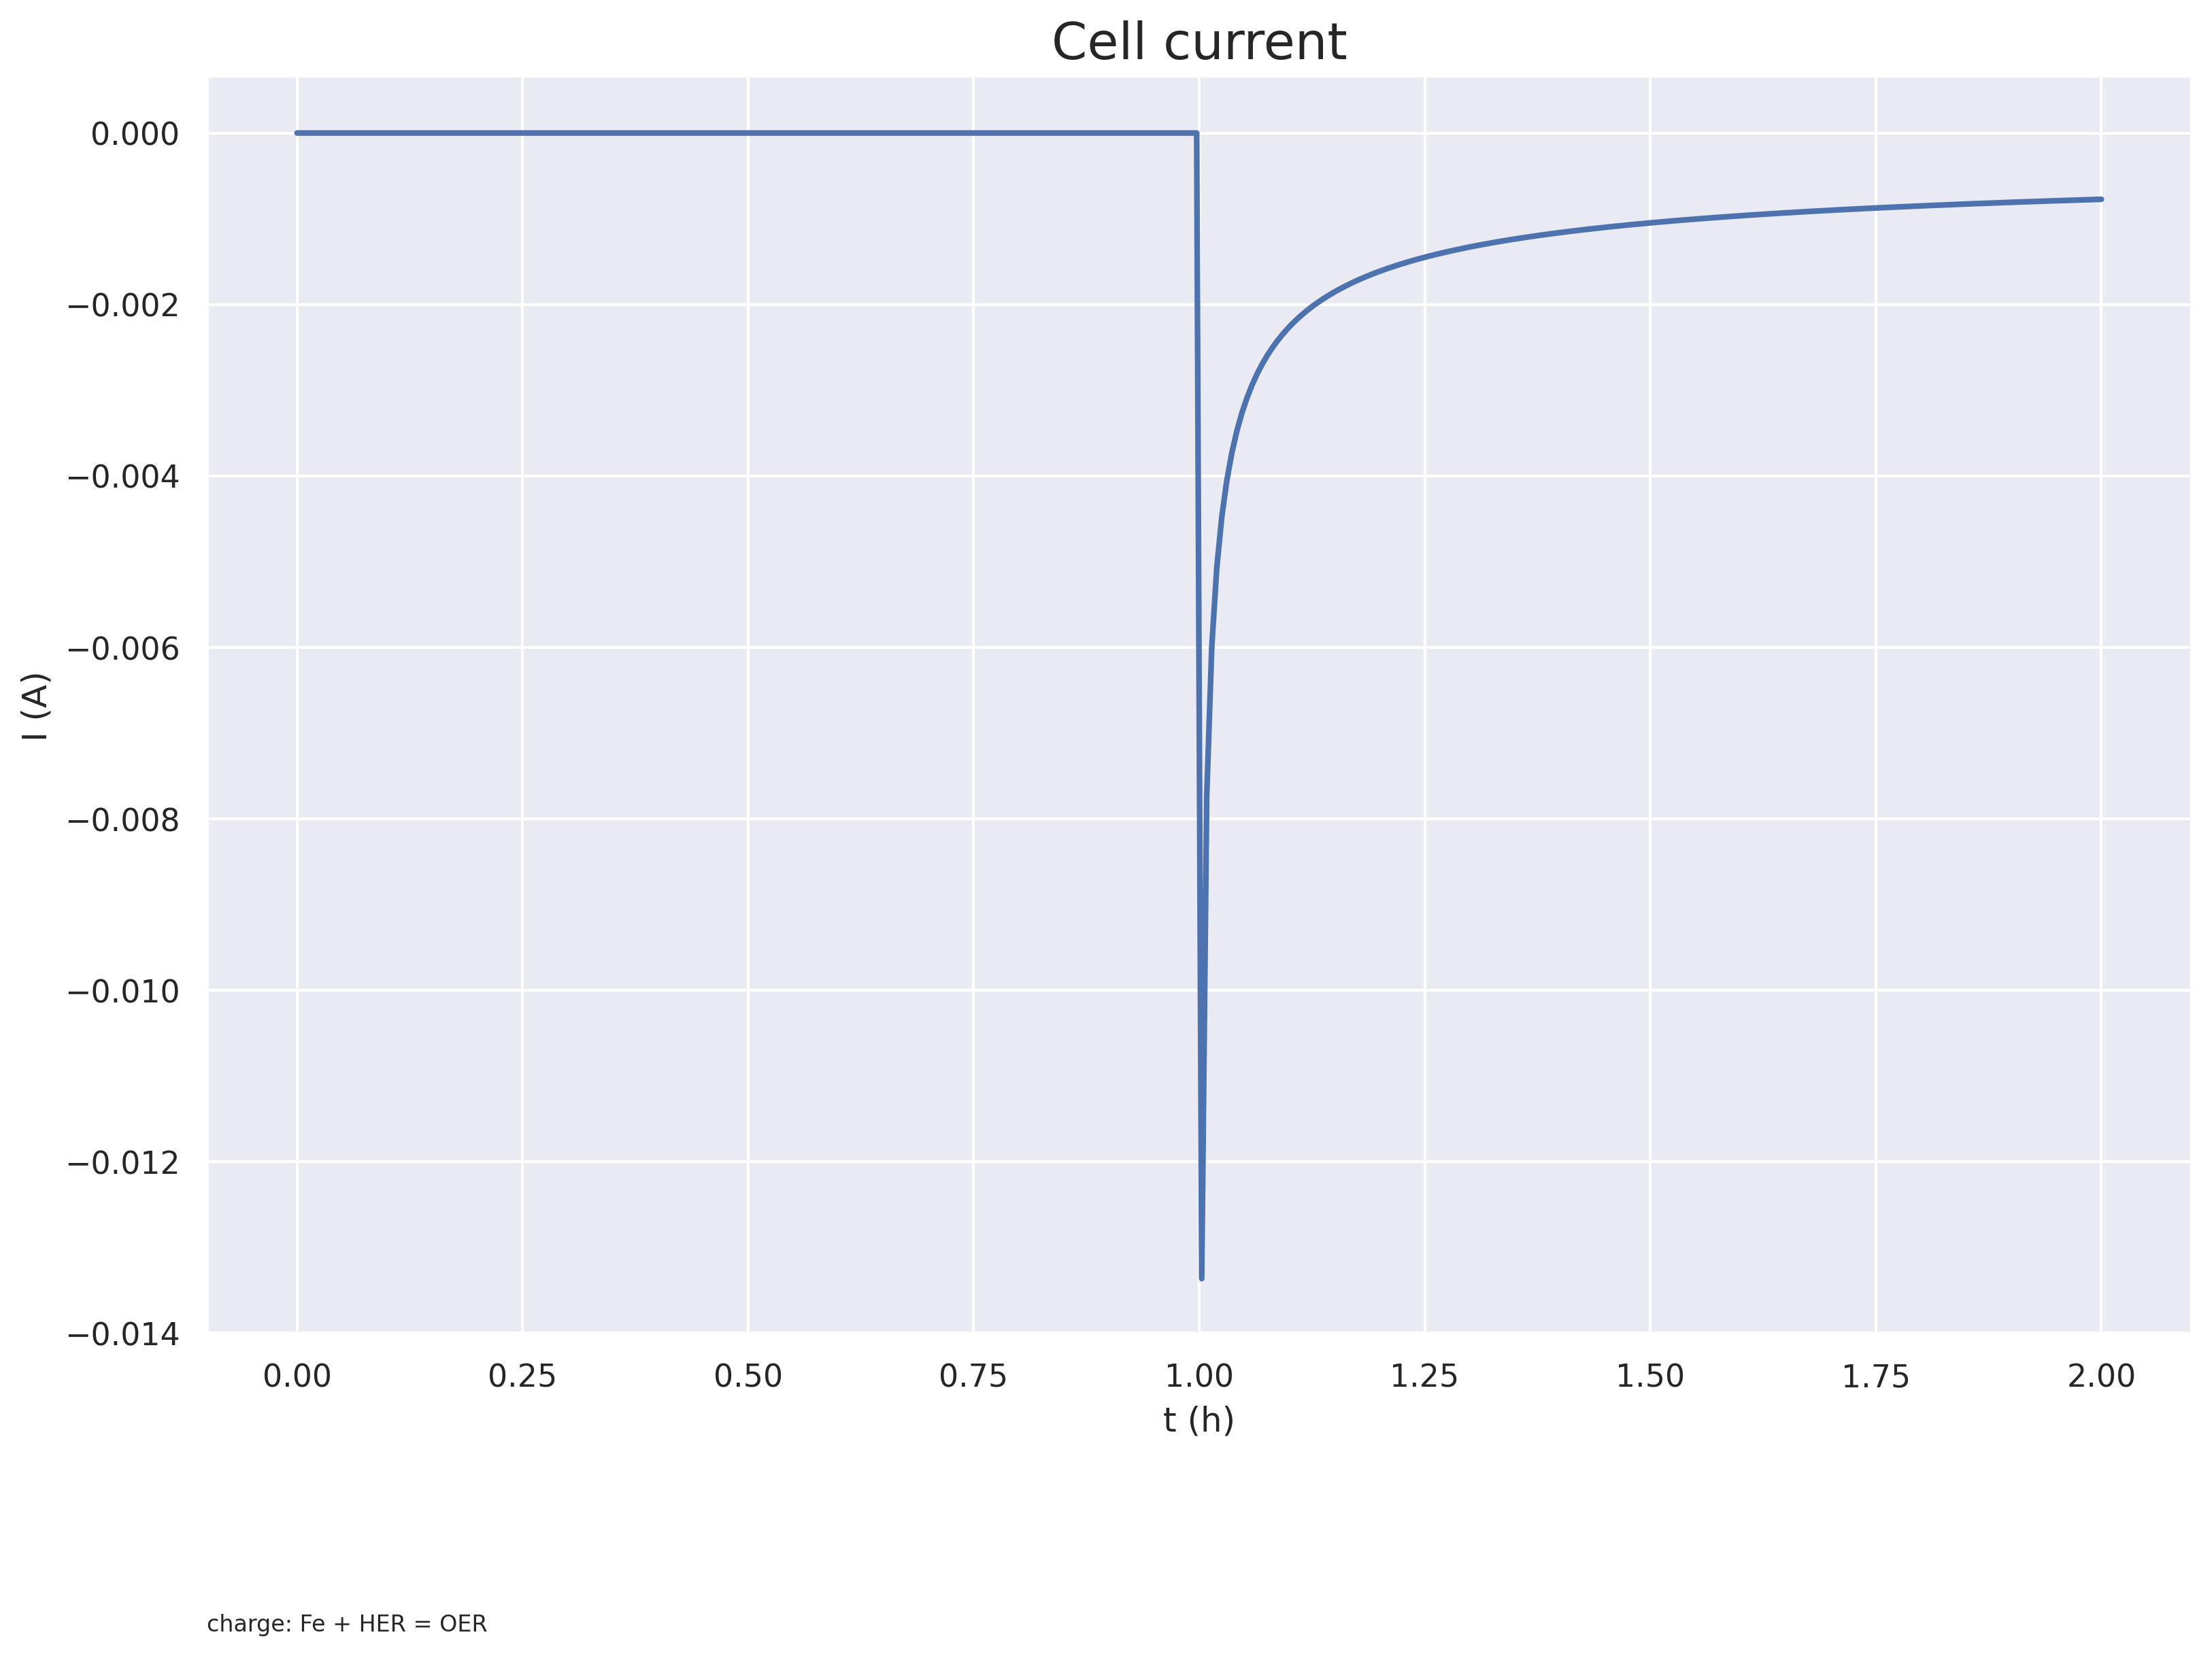

In [5]:
plot_frame = pd.DataFrame({"t": t / 3600, "I_A": a["I_cell_A"]})
fig, ax = plt.subplots()
sns.lineplot(data=plot_frame, x="t", y="I_A", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("I (A)")
ax.set_title("Cell current")
ax.text(0.0, -0.22, "charge: Fe + HER = OER", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Terminal voltage

### What this plot illustrates

Terminal voltage during fill/rest/first charge. Open-circuit-like at rest; rises under charge overpotential (Nernst + Butler–Volmer + ohmic).

### Governing equations

$V = V_\mathrm{Nernst}(a_\mathrm{OH},a_\mathrm{H_2O},T) + \eta_\mathrm{BV}(I,T) + IR$. Voltage in $\mathrm{V}$.


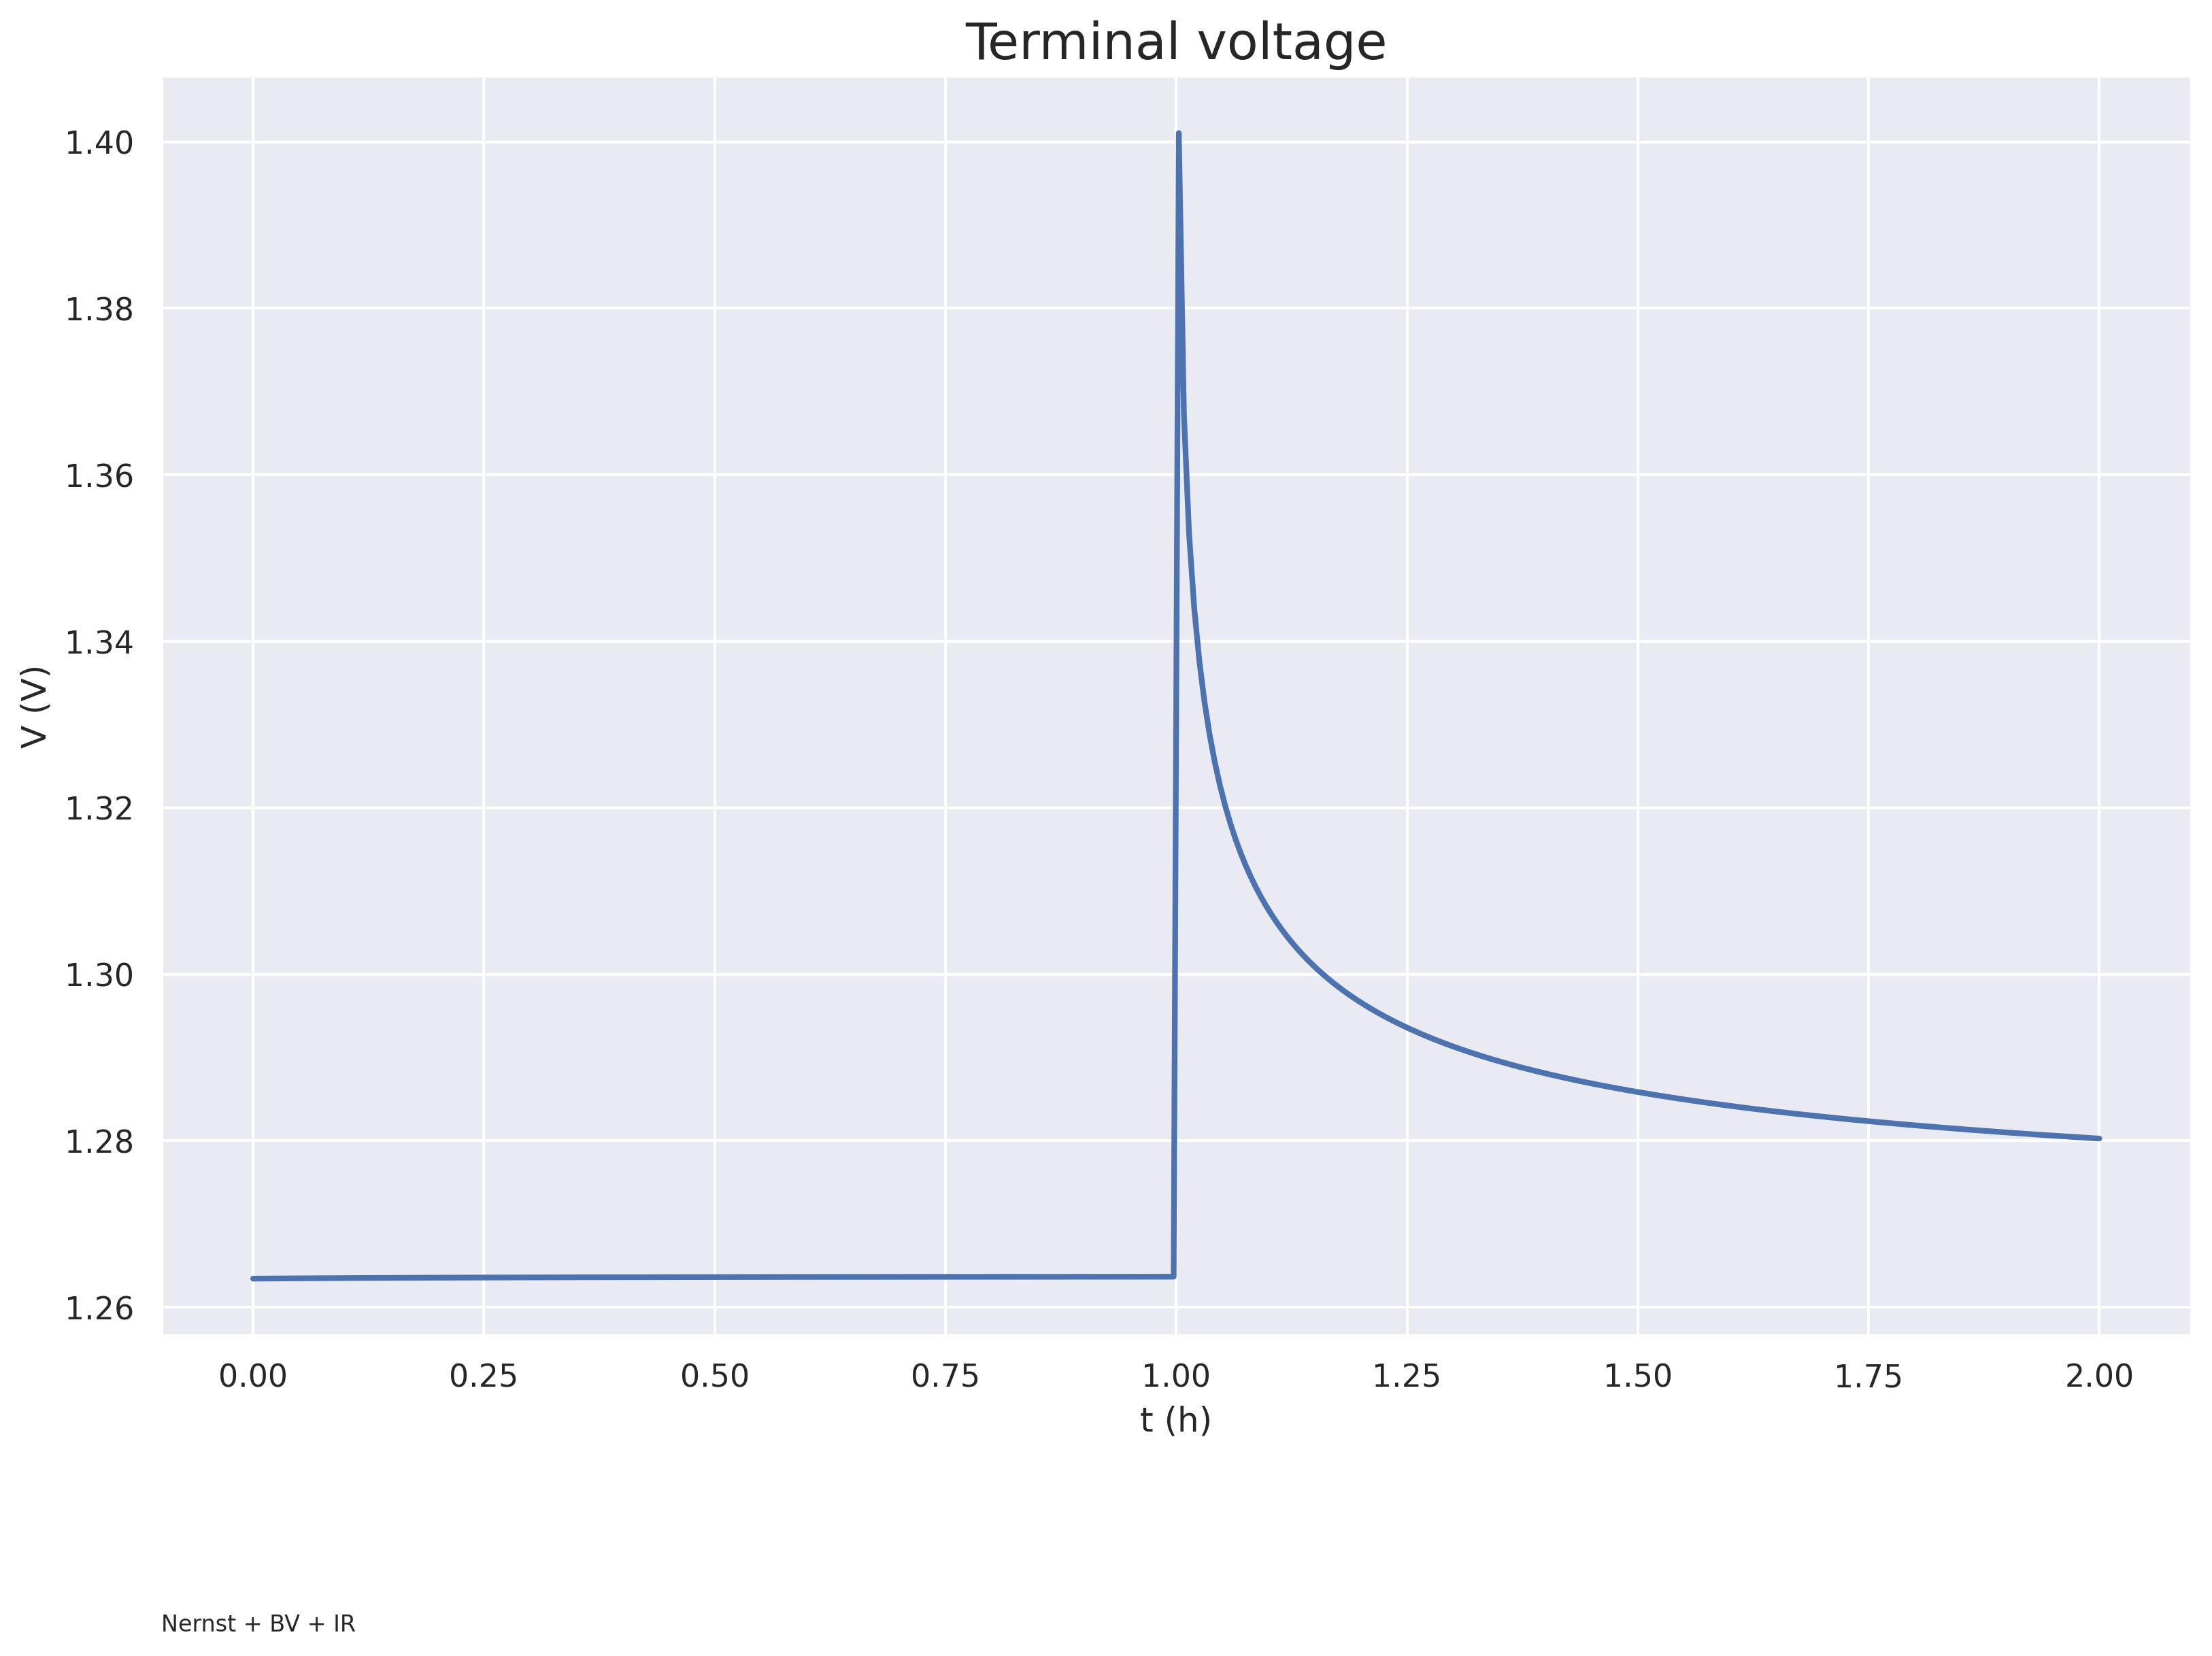

In [6]:
plot_frame = pd.DataFrame({"t": t / 3600, "V_V": a["V_cell_V"]})
fig, ax = plt.subplots()
sns.lineplot(data=plot_frame, x="t", y="V_V", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("V (V)")
ax.set_title("Terminal voltage")
ax.text(0.0, -0.22, "Nernst + BV + IR", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## KOH make-up fill and pore wetting

### What this plot illustrates

Dry vessel → $6\,\mathrm{M}$ KOH fill into anode pores. Tracks $n_\mathrm{OH}$, wetting saturation $s$, and electrolyte volume.

### Governing equations

Make-up: $\dot V_\mathrm{fill}=q_\mathrm{fill}(t)$, $c_\mathrm{KOH}\to 6\,\mathrm{M}$. Wetting ODE drives $s:0\to 1$ as pores fill.


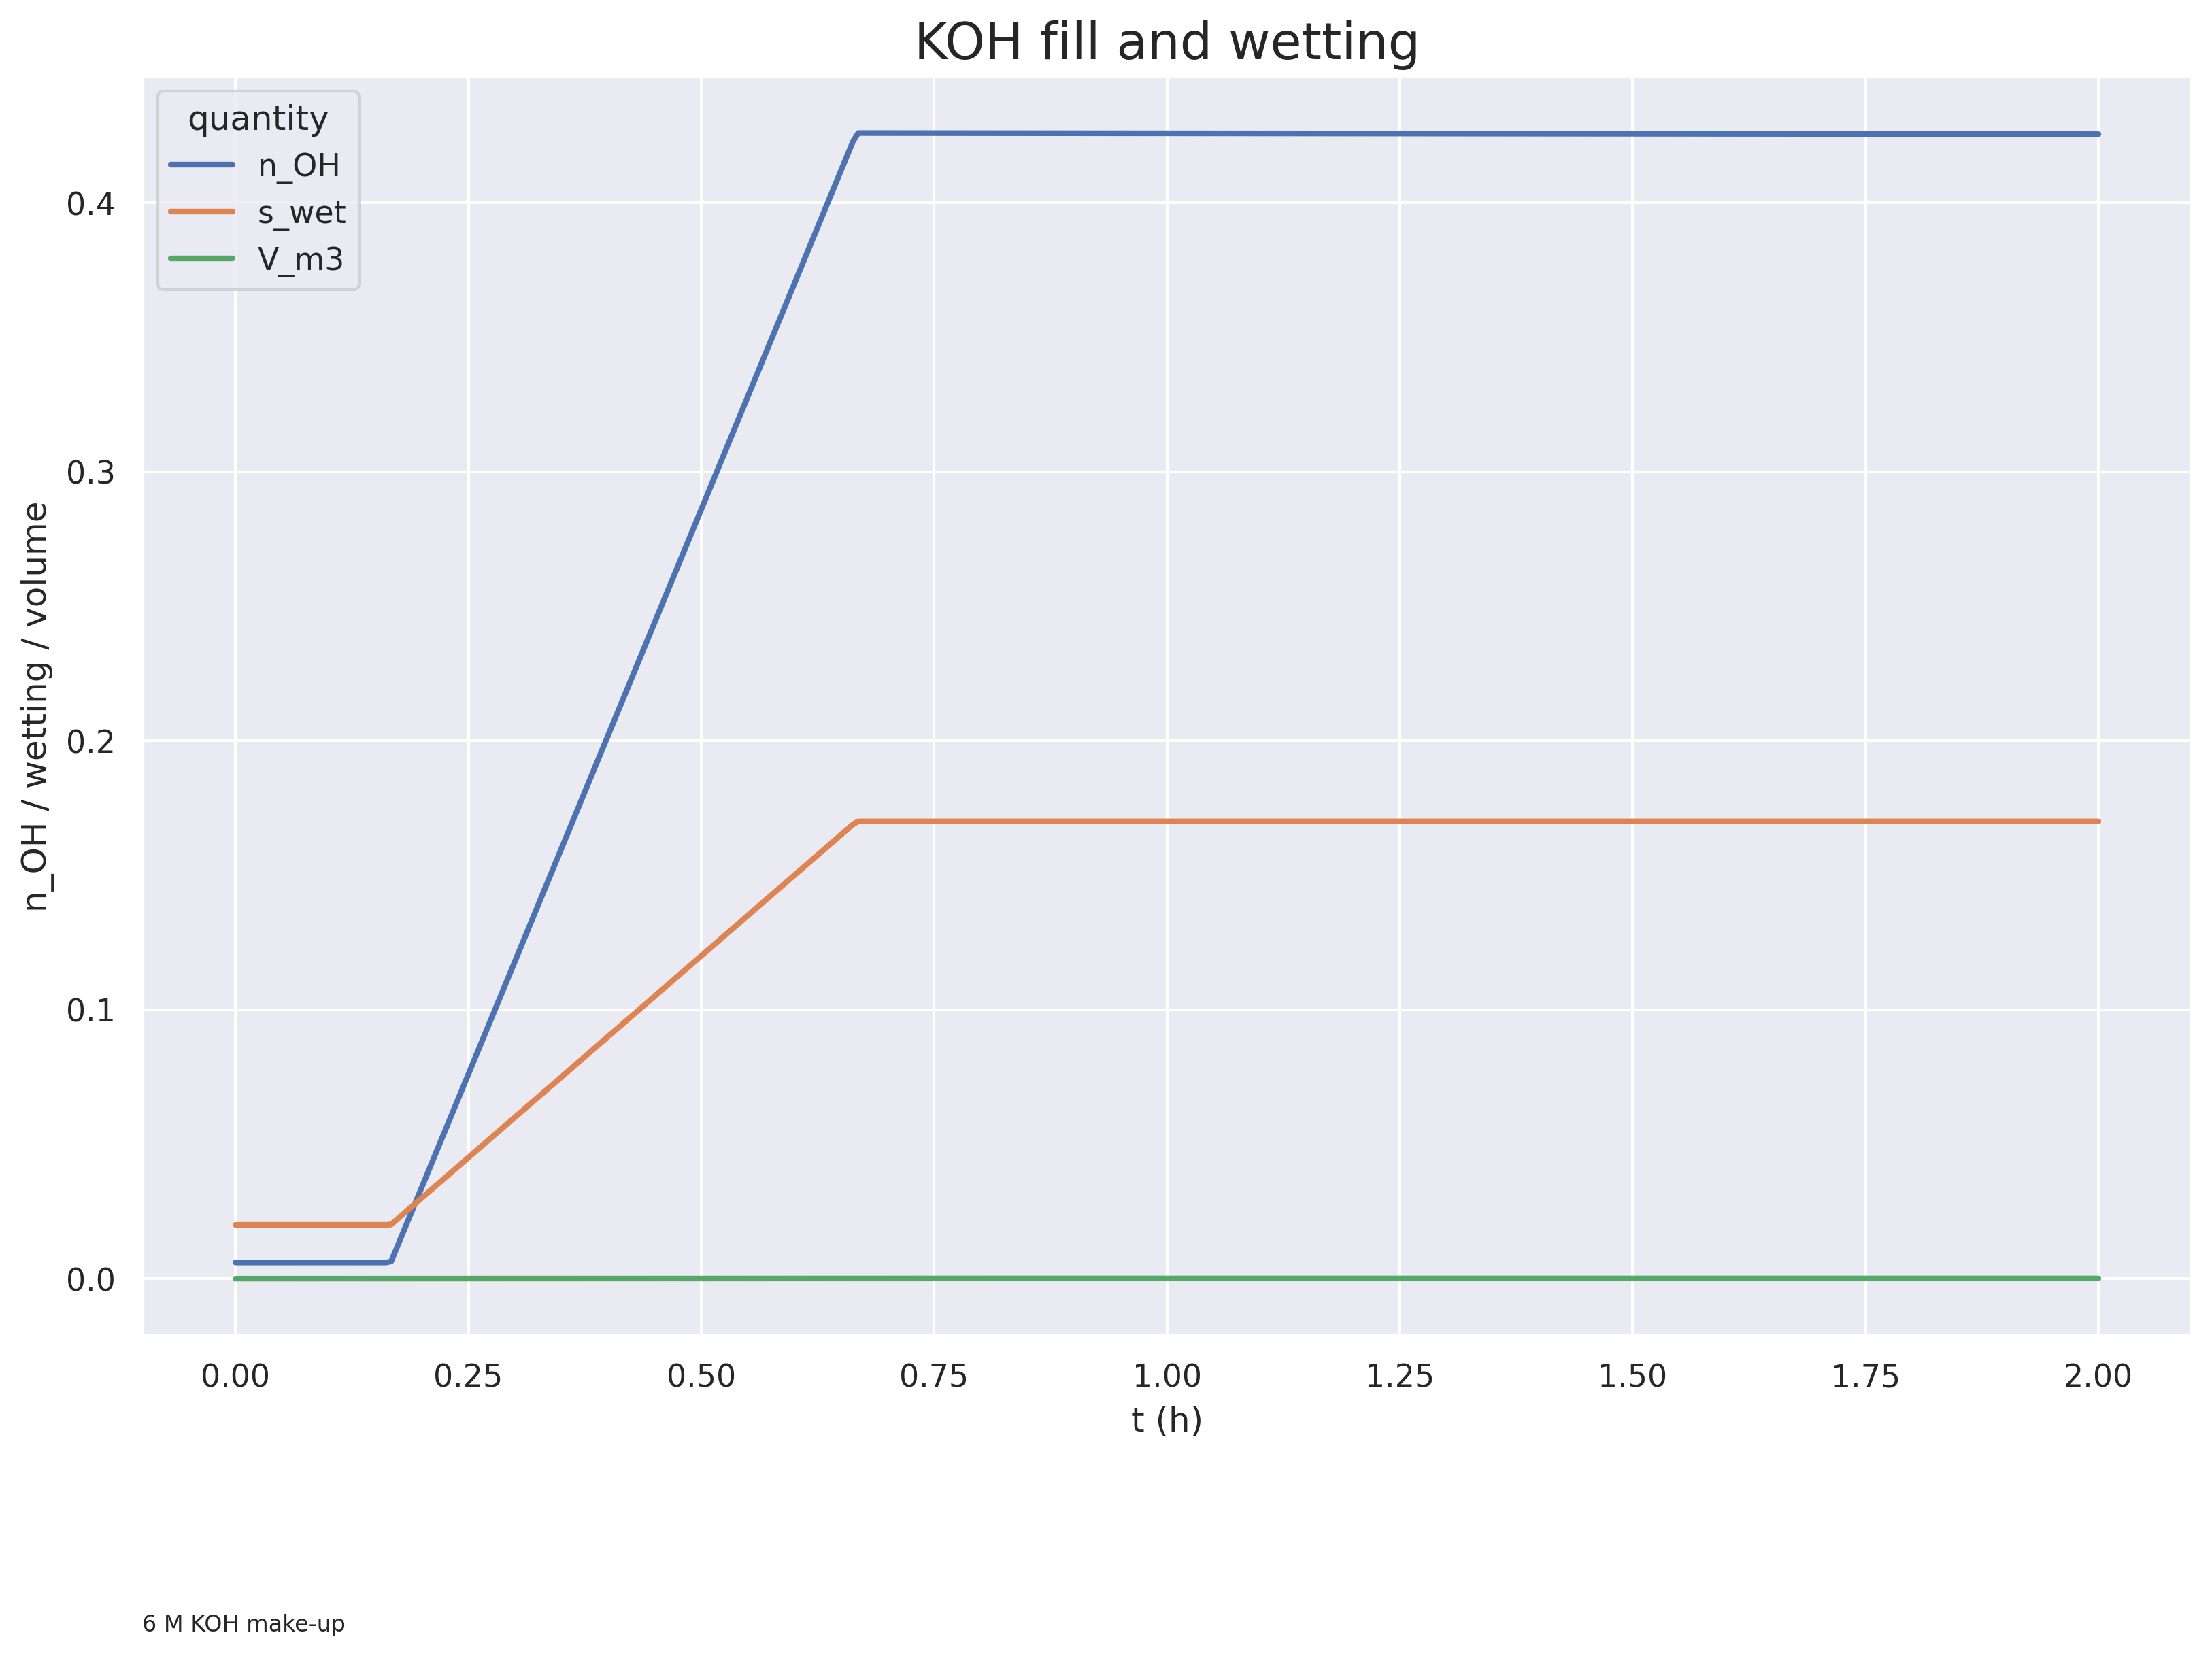

In [7]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 3600),
        "n_OH": (y[b["ely"][0]]),
        "s_wet": (y[b["ely"][0] + 6]),
        "V_m3": (y[b["ely"][0] + 5]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("n_OH / wetting / volume")
ax.set_title("KOH fill and wetting")
ax.text(0.0, -0.22, "6 M KOH make-up", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## First-charge gas evolution (OER + HER)

### What this plot illustrates

Oxygen from OER and parasitic $\mathrm{H_2}$ from HER during first grid charge, with coulombic efficiency.

### Governing equations

$$4\,\mathrm{OH^-} \to \mathrm{O_2} + 2\,\mathrm{H_2O} + 4\,\mathrm{e^-}$$

$$2\,\mathrm{H_2O} + 2\,\mathrm{e^-} \to \mathrm{H_2} + 2\,\mathrm{OH^-}$$

$\mathrm{CE}=I_\mathrm{Fe}/(I_\mathrm{Fe}+I_\mathrm{HER})$.


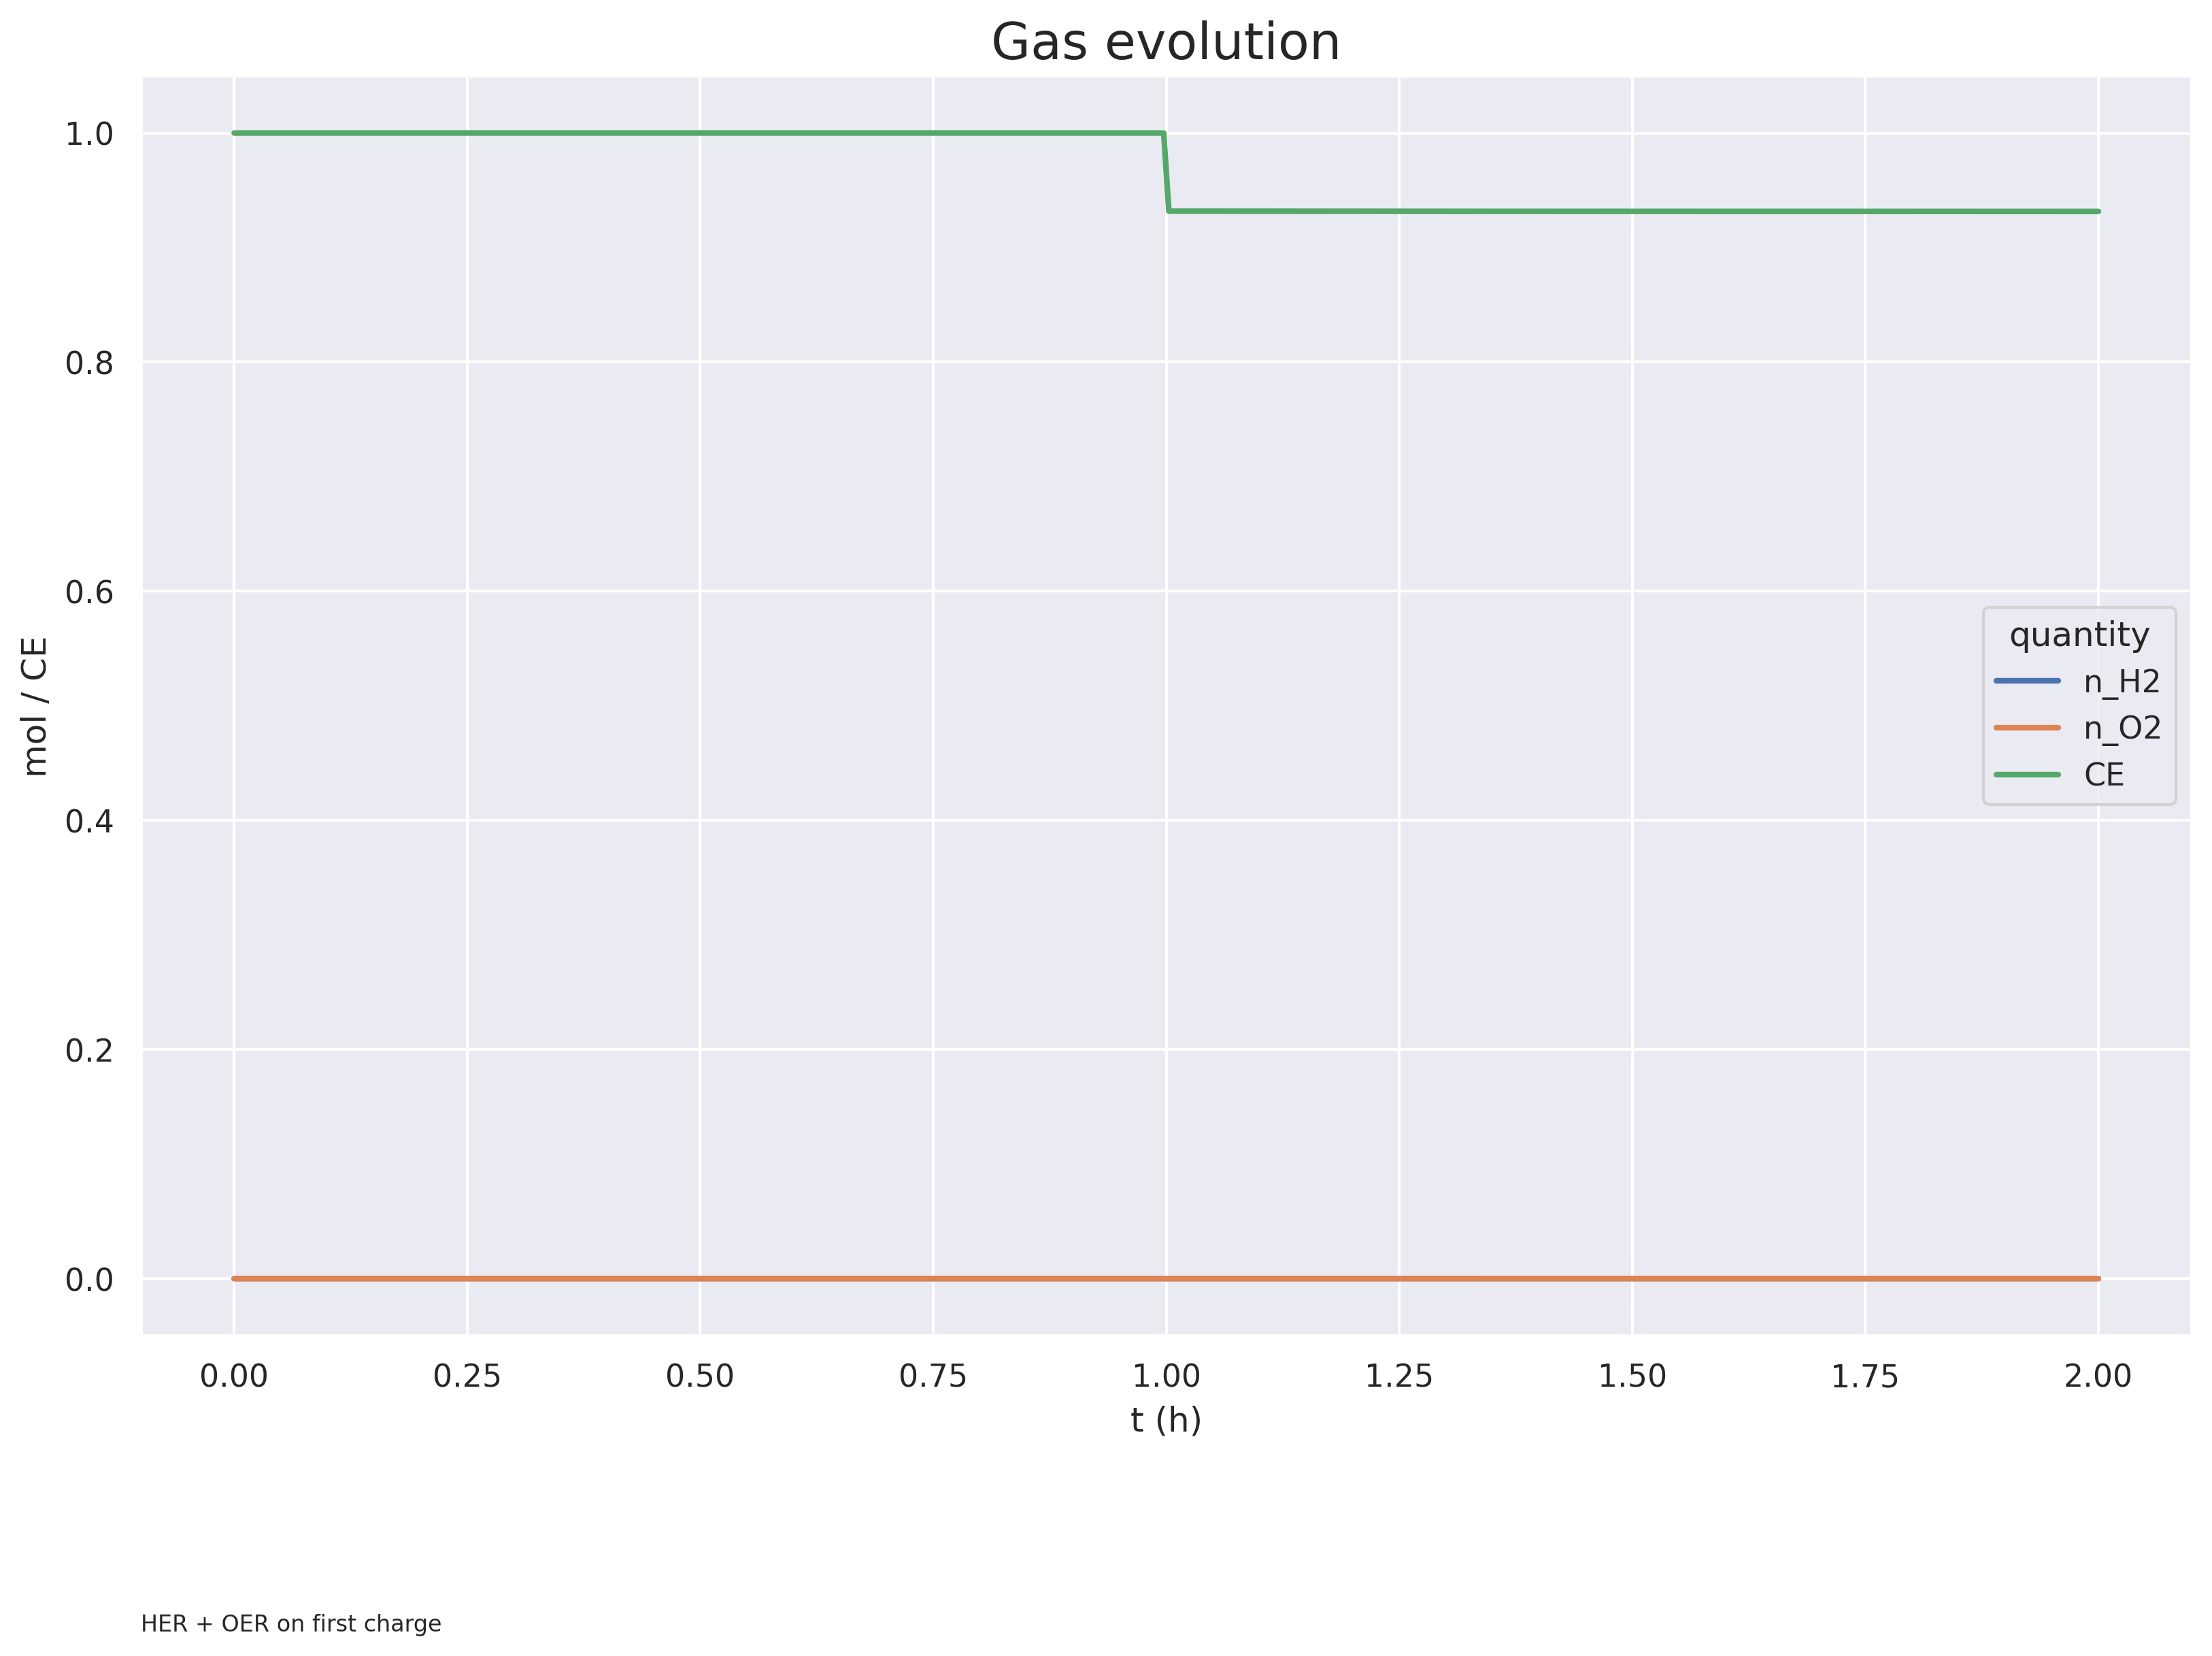

In [8]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 3600),
        "n_H2": (a["n_H2_mol"]),
        "n_O2": (a["n_O2_oer_mol"]),
        "CE": (a["CE"]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("mol / CE")
ax.set_title("Gas evolution")
ax.text(0.0, -0.22, "HER + OER on first charge", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Formation temperature rise

### What this plot illustrates

Electrode, electrolyte, and vessel temperatures during fill/rest/first charge. Heat from $I\eta$ and formation.

### Governing equations

$C\dot T = I\eta + UA(T_\infty-T) + \dot Q_\mathrm{fill}$. Temperatures in $\mathrm{K}$.


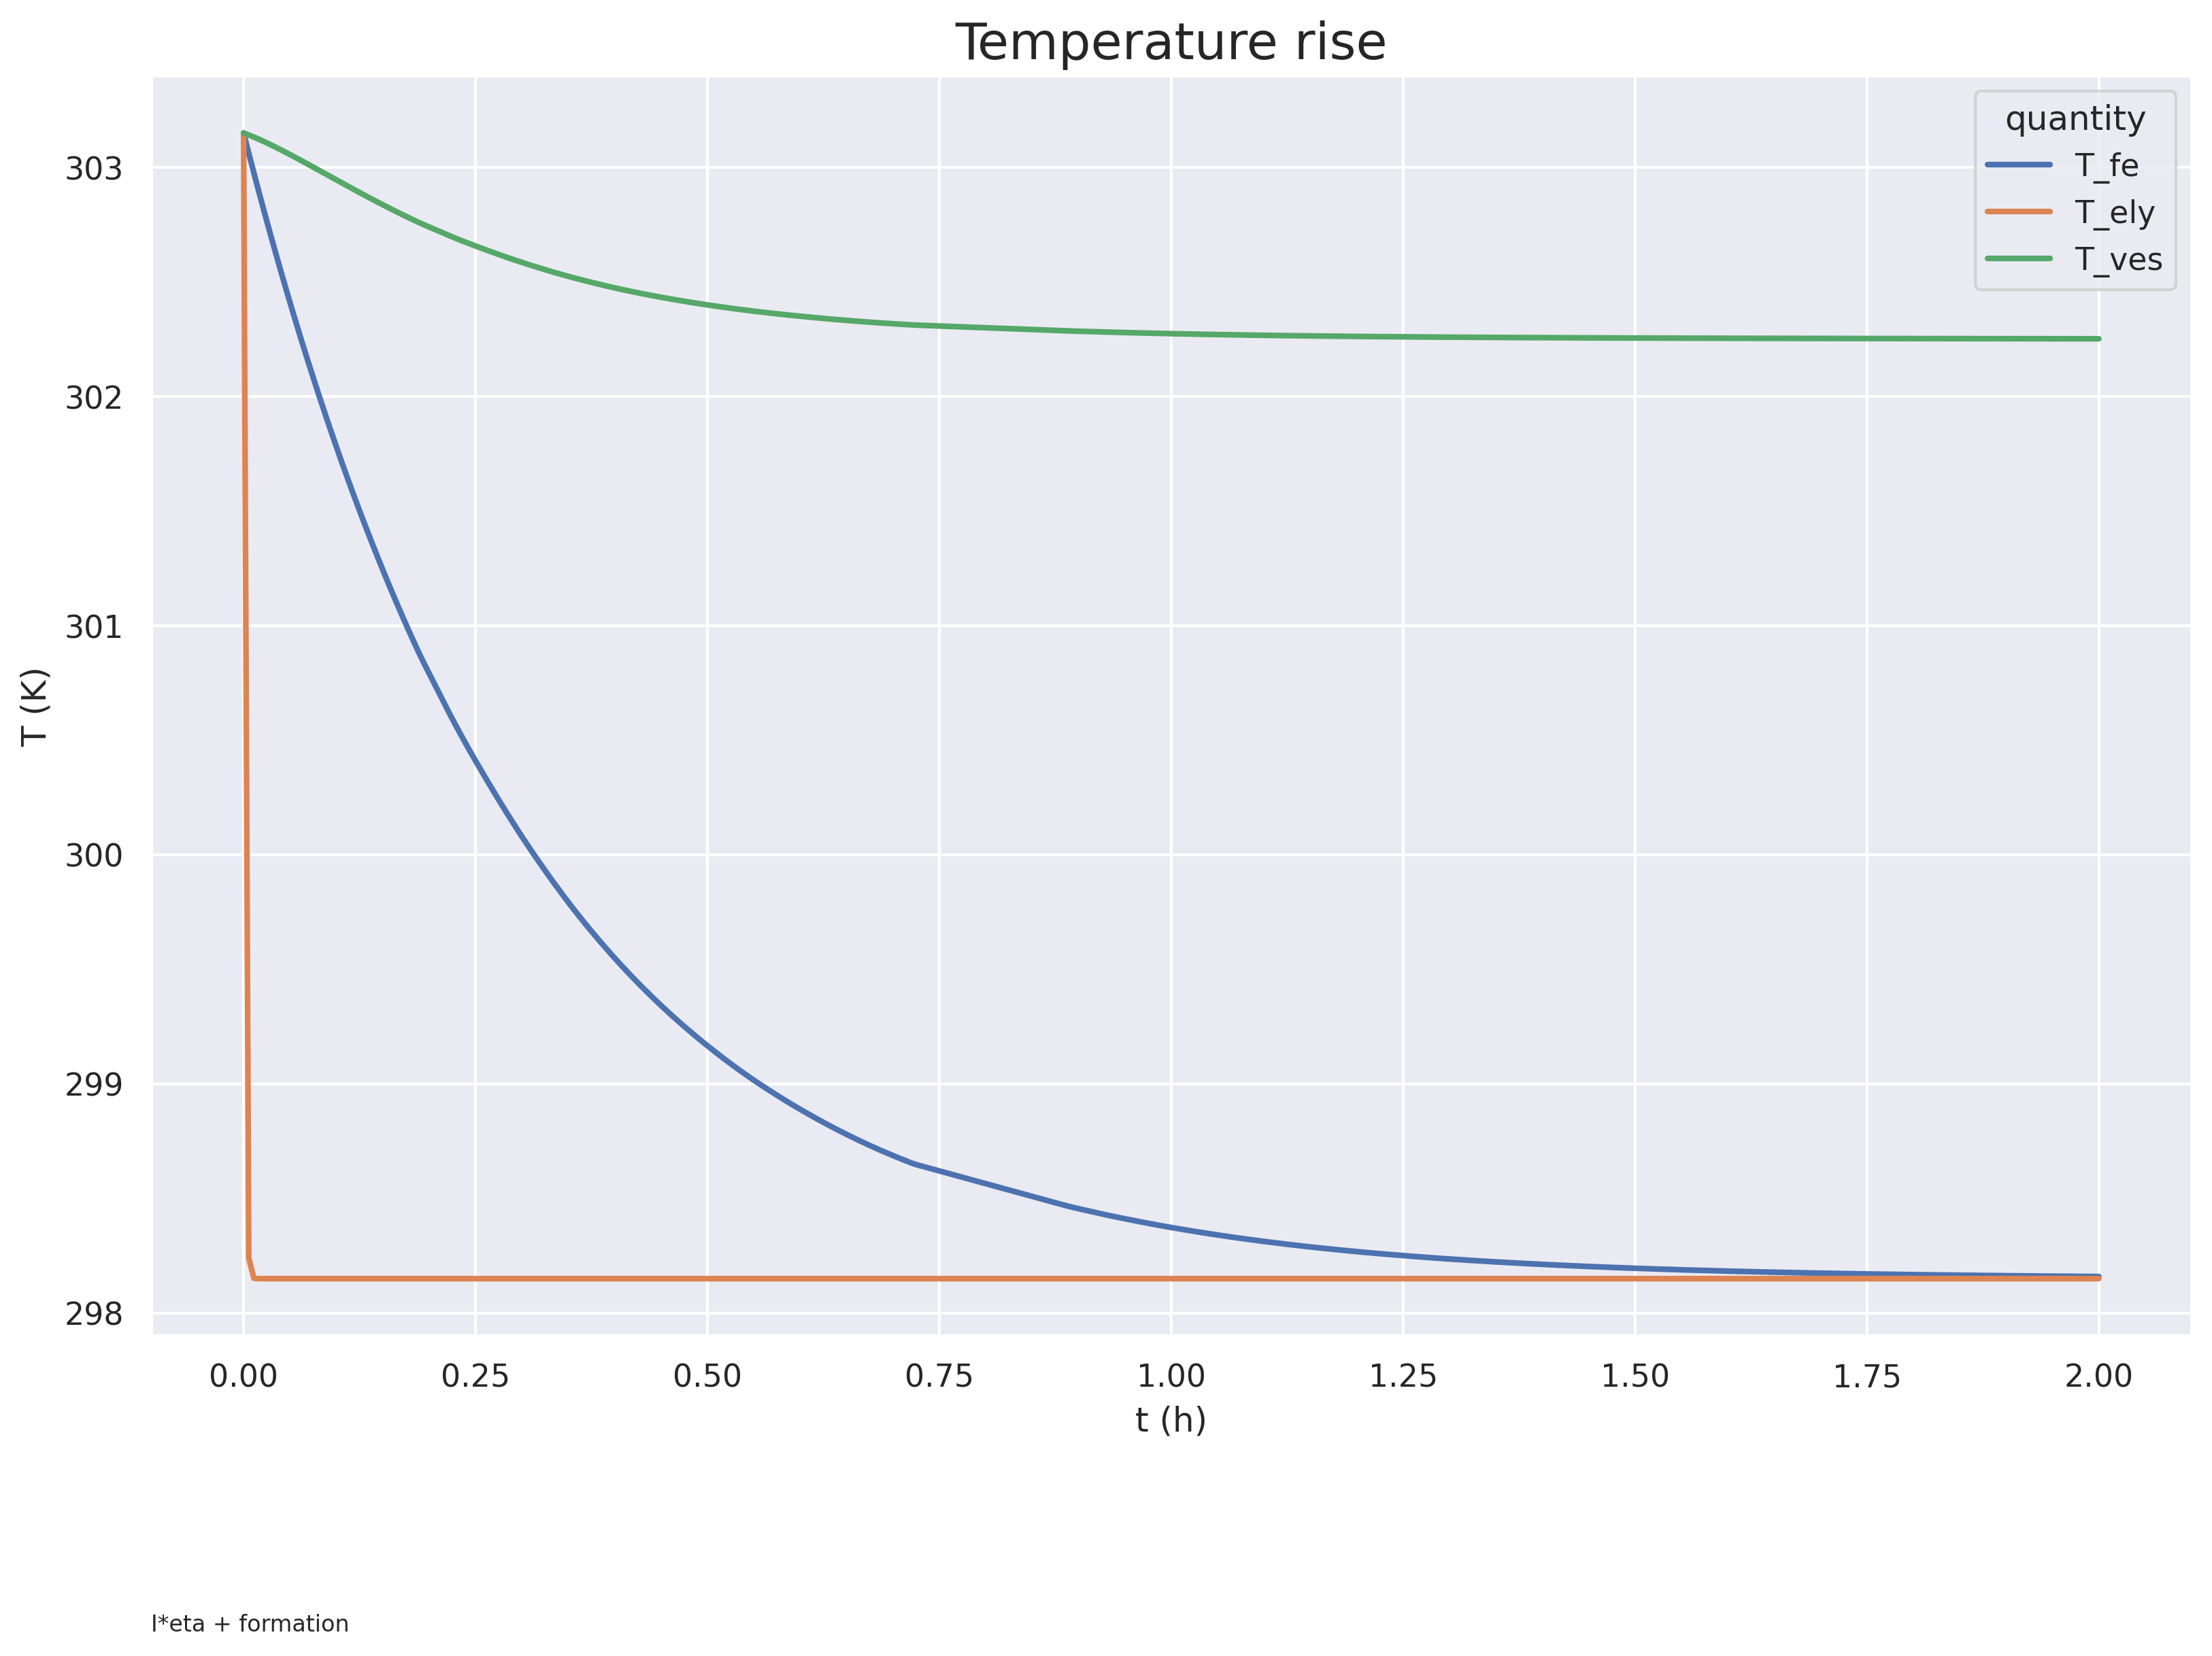

In [9]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 3600),
        "T_fe": (y[b["fe"][0] + 3]),
        "T_ely": (y[b["ely"][0] + 4]),
        "T_ves": (y[b["th"][0] + 2]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("T (K)")
ax.set_title("Temperature rise")
ax.text(0.0, -0.22, "I*eta + formation", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## SOC, carbonation, $p_{\mathrm{O_2}}$, and GDL saturation

### What this plot illustrates

State of charge recovery on first charge, carbonate inventory (air $\mathrm{CO_2}$ risk), oxygen partial pressure window, and GDL liquid saturation.

### Governing equations

$\mathrm{SOC}=1-n_\mathrm{Fe}/n_\mathrm{Fe,0}$ (model convention). Carbonation: $\mathrm{CO_2}+2\,\mathrm{OH^-}\to\mathrm{CO_3^{2-}}+\mathrm{H_2O}$. $p_{\mathrm{O_2}}$ in atm; $s_\mathrm{GDL}\in[0,1]$.


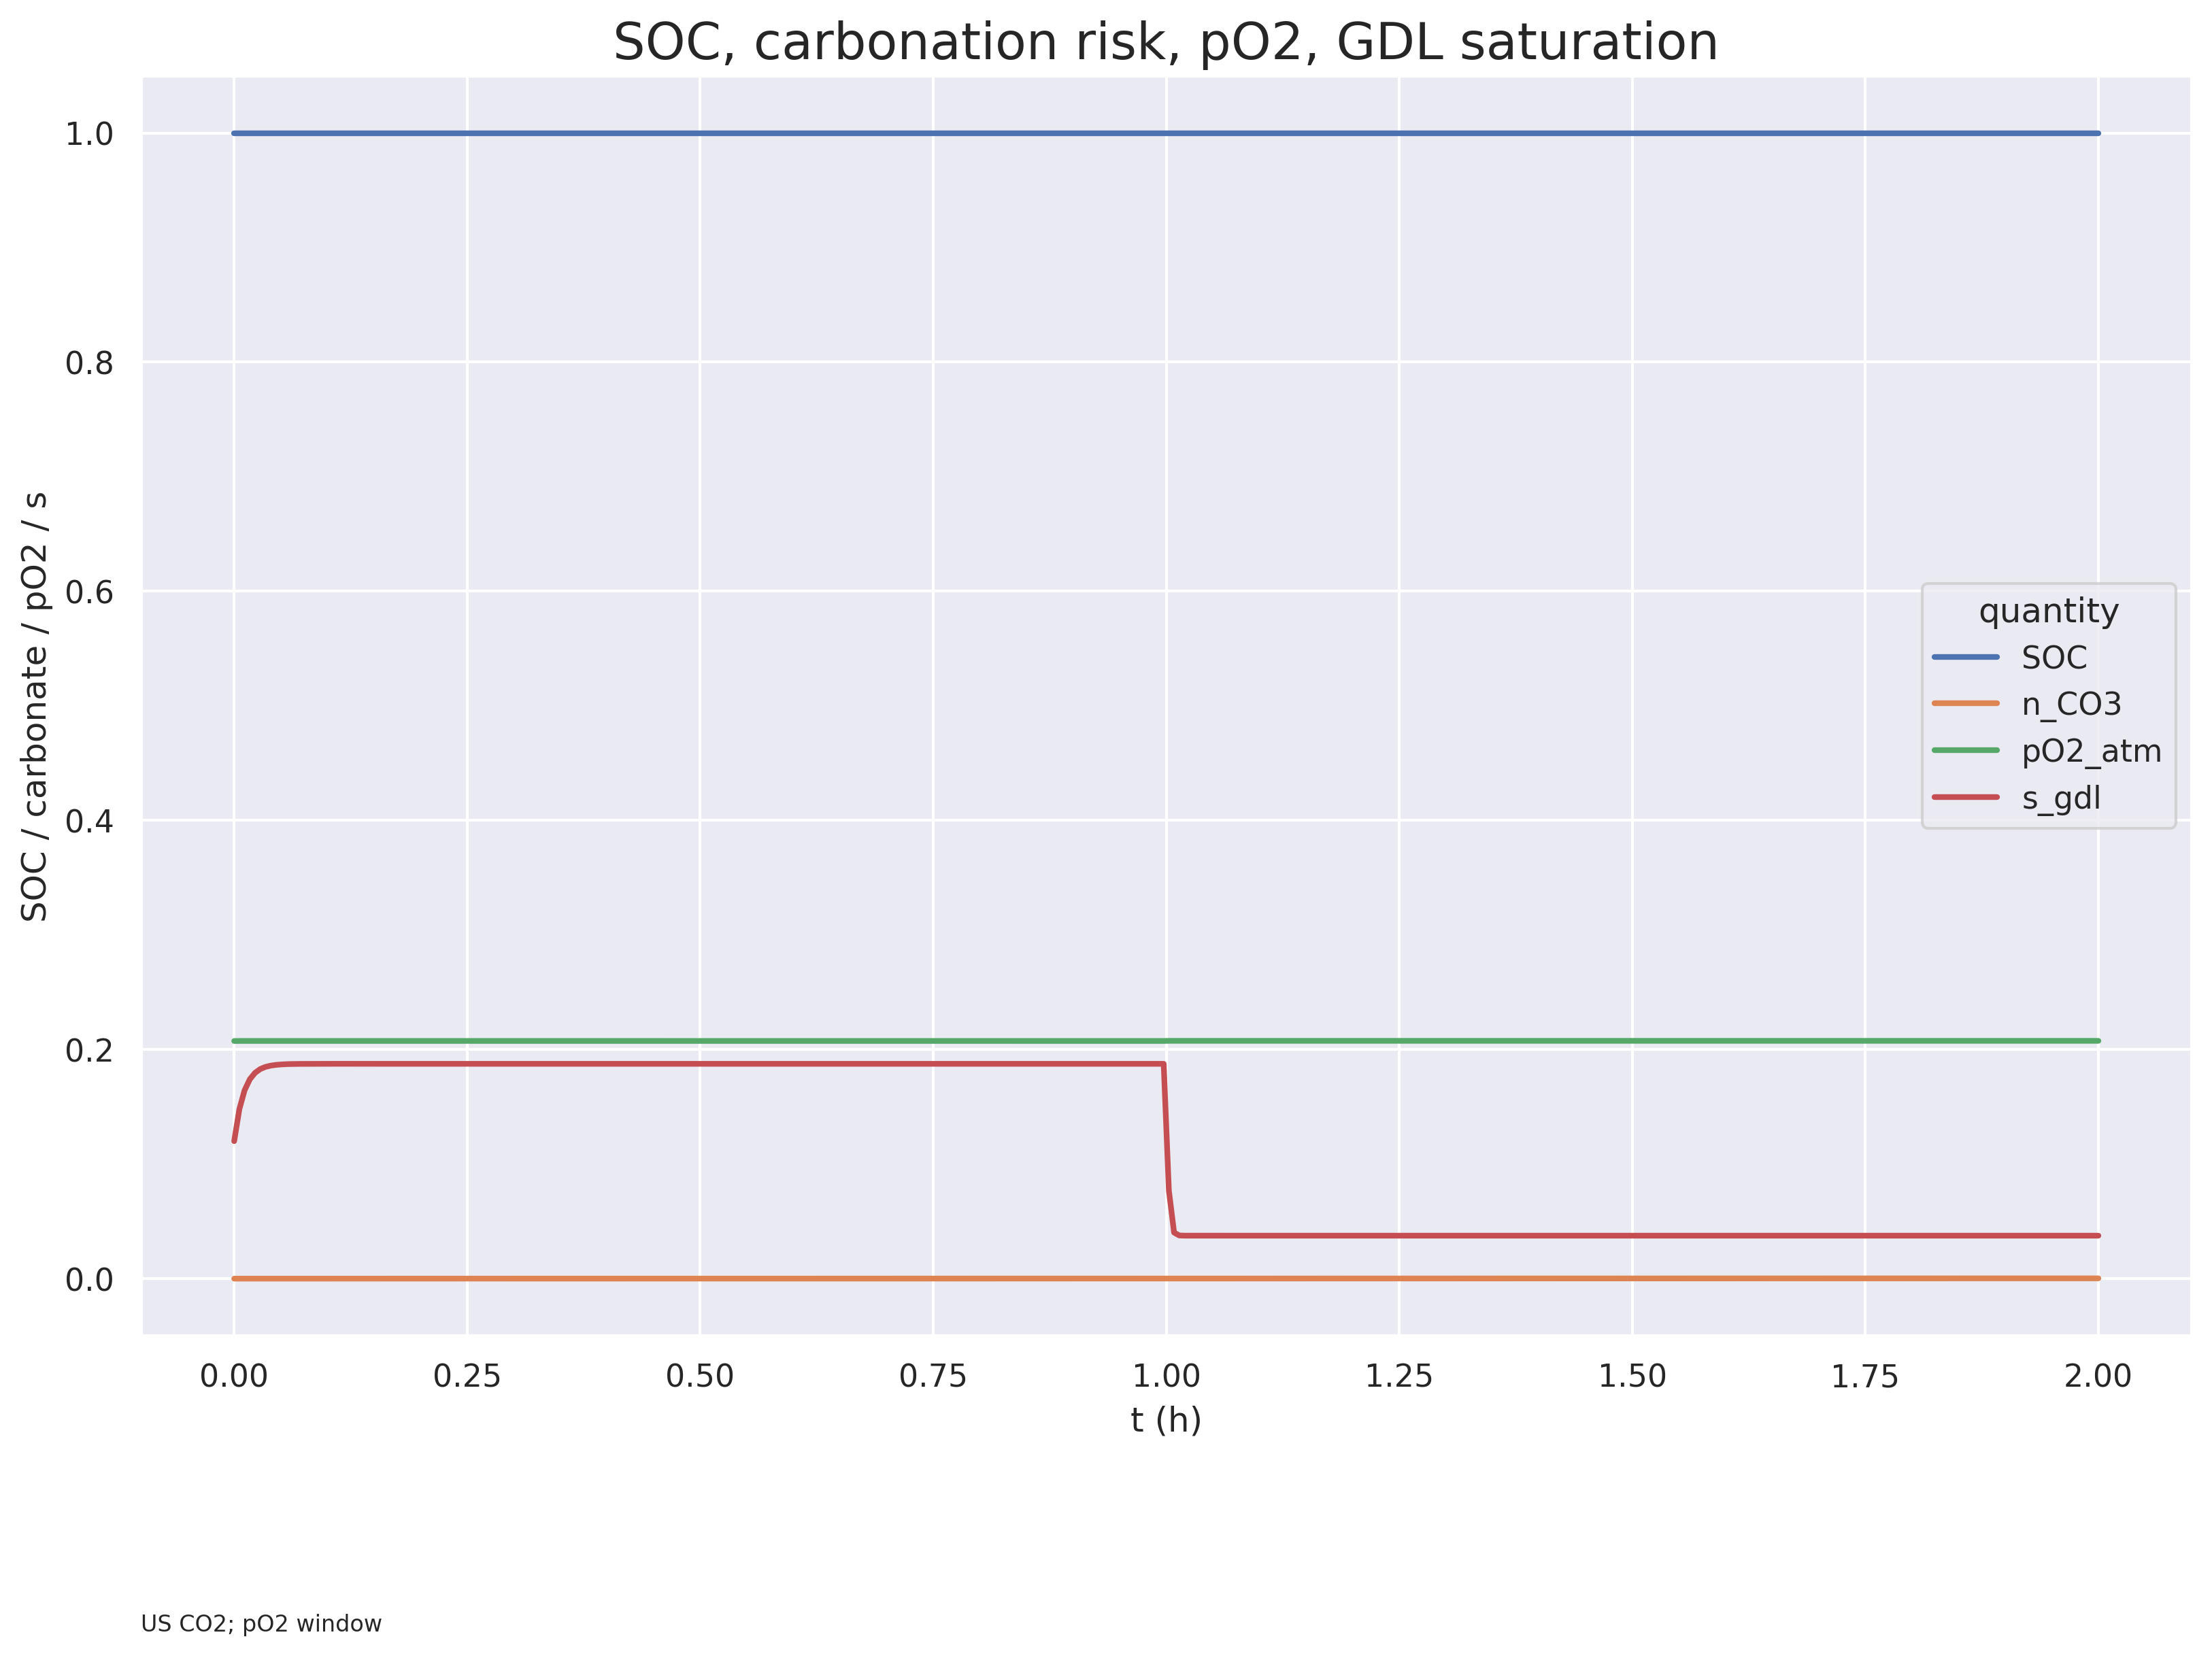

In [10]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 3600),
        "SOC": (a["SOC"]),
        "n_CO3": (y[b["ely"][0] + 2]),
        "pO2_atm": (a["p_O2_Pa"] / P.P_atm_Pa),
        "s_gdl": (a["s_gdl"]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("SOC / carbonate / pO2 / s")
ax.set_title("SOC, carbonation risk, pO2, GDL saturation")
ax.text(0.0, -0.22, "US CO2; pO2 window", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Numerical checks

Finite-trajectory and capacity checks for the integration above.


In [11]:
print("finite", np.all(np.isfinite(y)), "nfev", res["nfev"])

finite True nfev 1187


## Verification against patents / SSS002

In [12]:
assert np.all(np.isfinite(y))
print("PASS finite commissioning trajectory")

PASS finite commissioning trajectory
